In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time

import os, sys
sys.path.append(os.path.abspath("../.."))

# Select the backend before importing folps.py
os.environ["FOLPS_BACKEND"] = "numpy"  #'numpy' or 'jax'

from folps import *
from cosmo_class import *

✅ Using NumPy with CPU.


In [2]:
#omega_i = Omega_i h² 
omega_b = 0.0224;        #baryons
omega_cdm = 0.12;       #CDM
omega_ncdm = 0.00;    #massive neutrinos 
h = 0.67;                 #h = H0/100
z_pk = 0.01;                 #evaluation redshift

Linear power spectrum at redshift z_pk:

In [3]:
ps = run_class(h = h, ombh2 = omega_b, omch2 = omega_cdm, omnuh2 = omega_ncdm,
                 As = np.exp(3)/(10**10), ns = 0.9649, z = z_pk)

Omega_mnu = (0.06/(93.14 * h**2))
Omega_m = (omega_cdm + omega_b)/h**2 + Omega_mnu

kwargs = {'z': z_pk, 'h': h, 'Omega_m': Omega_m, #'f0':0.6900011469771554,
              'fnu':Omega_mnu/Omega_m}
    
inputpkT = ps['k'], ps['pk']


Nuisance parameters for the linear power spectrum:

Define a vector with the nuisances parameters, NuisanParams = [b1, b2, bs2, b3nl, alpha0, alpha2, alpha4, ctilde, alphashot0, alphashot2, PshotP]

In [4]:
#bias parameters
b1 = 1;                 
b2 = 2;                 
bs2 = -4/7*(b1 - 1);        
b3nl = 32/315*(b1 - 1);  

#EFT parameters
alpha0, alpha2, alpha4 = -10,-3,2#-10,-3,2    # PEFT(k) = (alpha0 + alpha2*mu^2+ alpha4*mu^4)  k^2 Plin(k)
ctilde = 0               #NLO counterterm
X_FoG = 1  # uses a Lorentzian Damping 1/(1+x^2), with x = X_FoG f sigma_v mu. 

#Stochatics parameters
# Noise is Pshot = PshotP * ( alphashot0 + alphashot2*(k*mu)**2 )
alphashot0 = 2;          
alphashot2 = 1;            
PshotP = 1/0.002    # =1/barn.  Poissonian shot noise
NuisanParams = [b1, b2, bs2, b3nl, alpha0, alpha2, alpha4, ctilde, alphashot0, alphashot2, PshotP,X_FoG]

#### Computation of $M$ matrices 
**They do not depend on the cosmology**, so they are **computed only one time**. That is, the first time the code is called, it computes the $M$ matrices and stores them for the rest of the runs, which can be of the order of thousands in parameter estimations.

In [5]:
matrix = MatrixCalculator(A_full=False)
mmatrices = matrix.get_mmatrices()

Loading matrices from matrices_nfftlog128_Afull_False_remove-DeltaP_False.npy


In [6]:
Omfid = 0.31519186799  # for AP set > 0

In [7]:
# output k_ev
k_ev = np.logspace(np.log10(0.01), np.log10(0.3), num = 100) # array of k_ev in [h/Mpc]

In [8]:
qpar, qper = qpar_qperp(Omega_fid=Omfid, Omega_m=kwargs['Omega_m'], z_pk=kwargs['z'])

In [9]:
nonlinear_hn = NonLinearPowerSpectrumCalculator(mmatrices=mmatrices,
                                             kernels='fk',
                                             **kwargs)

In [10]:
table, table_now = nonlinear_hn.calculate_loop_table(k=inputpkT[0], pklin=inputpkT[1],cosmo=None, **kwargs)

In [11]:
multipoles = RSDMultipolesPowerSpectrumCalculator(model='FOLPSD') 

In [12]:
P0, P2, P4  = multipoles.get_rsd_pkell(kobs=k_ev, qpar=qpar, qper=qper, pars=NuisanParams,
                                       table=table, table_now=table_now,
                                       bias_scheme='folps', damping='lor', 
                                       )

[FOLPS] Model Pk: FOLPSD, Damping: lor


In [13]:
P0_c, P2_c, P4_c  = get_rsd_pkell_marg_const(kobs=k_ev, qpar=qpar, qper=qper, pars=NuisanParams,
                                       table=table, table_now=table_now,
                                       bias_scheme='folps', damping='lor', model = 'FOLPSD'
                                       )

[FOLPS] Model Pk: FOLPSD, Damping: lor


In [14]:
P0_i, P2_i, P4_i  = get_rsd_pkell_marg_derivatives(kobs=k_ev, qpar=qpar, qper=qper, pars=NuisanParams,
                                       table=table, table_now=table_now,
                                       bias_scheme='folps', damping='lor', model = 'FOLPSD'
                                       )

In [15]:
P0_marg = P0_c + (P0_i[0] * alpha0 + P0_i[1] * alpha2 + P0_i[2] * alpha4 + P0_i[3] * alphashot0 + P0_i[4] * alphashot2)
P2_marg = P2_c + (P2_i[0] * alpha0 + P2_i[1] * alpha2 + P2_i[2] * alpha4 + P2_i[3] * alphashot0 + P2_i[4] * alphashot2)

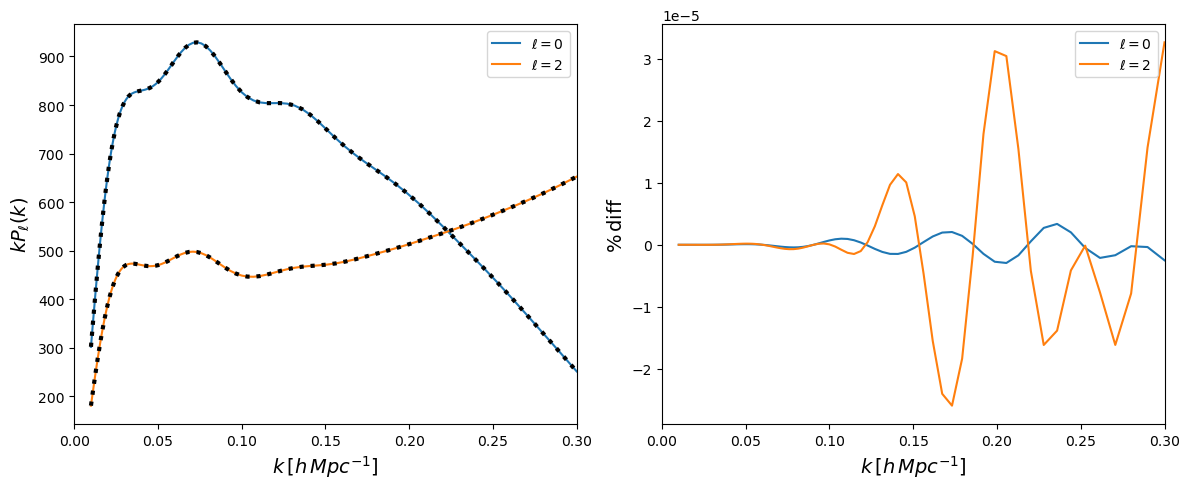

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

axs[0].set_xlabel(r'$k \, [h\, Mpc^{-1}]$', fontsize=14)
axs[0].set_ylabel(r'$ k  P_{\ell}(k)$', fontsize=14)

axs[0].plot(k_ev, k_ev*P0_marg, label=r'$\ell = 0$')
axs[0].plot(k_ev, k_ev*P2_marg, label=r'$\ell = 2$')

axs[0].plot(k_ev, k_ev*P0, lw=3, ls=':', color='k')
axs[0].plot(k_ev, k_ev*P2, lw=3, ls=':', color='k')

axs[0].set_xlim([0, 0.3])
axs[0].legend()

axs[1].set_xlabel(r'$k \, [h\, Mpc^{-1}]$', fontsize=14)
axs[1].set_ylabel(r'$\% \, \mathrm{diff}$', fontsize=14)

diff0 = 100 * (P0_marg - P0) / (P0)
diff2 = 100 * (P2_marg - P2) / (P2)

axs[1].plot(k_ev, diff0, label=r'$\ell = 0$')
axs[1].plot(k_ev, diff2, label=r'$\ell = 2$')

axs[1].set_xlim([0, 0.3])
axs[1].legend()

plt.tight_layout()
plt.show()

In [17]:
P4

array([1333.8481965 , 1350.43248294, 1366.16329582, 1380.94536492,
       1394.67512268, 1407.28258657, 1418.69843976, 1428.84250157,
       1437.6155004 , 1444.92580631, 1450.69608093, 1454.85435988,
       1457.31829286, 1457.99417427, 1456.79873355, 1453.67401988,
       1448.58604167, 1441.47927143, 1432.29058598, 1420.96567613,
       1407.50654251, 1391.92923164, 1374.23579686, 1354.43079664,
       1332.56221701, 1308.74397258, 1283.07155198, 1255.63311267,
       1226.52595979, 1195.90849307, 1163.99209569, 1131.02103955,
       1097.23382937, 1062.86557025, 1028.1451847 ,  993.28173342,
        958.50742254,  924.13989113,  890.48174024,  857.79275423,
        826.26261988,  796.05515427,  767.31620626,  740.16714145,
        714.67137459,  690.84293548,  668.69626771,  648.1892866 ,
        629.20704804,  611.57807403,  595.1100769 ,  579.60268532,
        564.84811002,  550.63311857,  536.75481217,  523.0704608 ,
        509.47910756,  495.92809332,  482.45527722,  469.16581